# Hyperparameter Tuning with Optuna

# Hyperparameter Tuning with Optuna

In this hands-on demo, you will learn how to leverage **Optuna**, a powerful optimization library, for efficient model tuning. We'll guide you through the process of performing **hyperparameter optimization**, demonstrating how to define the search space, objective function, and algorithm selection. Throughout the demo, you will utilize *MLflow* to seamlessly track the model tuning process, capturing essential information such as hyperparameters, metrics, and intermediate results. By the end of the session, you will not only grasp the principles of hyperparameter optimization but also be proficient in finding the best-tuned model using various methods such as the **MLflow API** and **MLflow UI**.

By integrating Optuna and MLflow, you can efficiently optimize hyperparameters and maintain comprehensive records of your machine learning experiments, facilitating reproducibility and collaborative research.

### Learning Objectives:

*By the end of this demo, you will be able to:*

* Perform hyperparameter optimization using Optuna.
* Track the model tuning process with MLflow.
* Query previous runs from an experiment using the `MLflowClient`.
* Review an MLflow Experiment for visualizing results and selecting the best run.
* Read in the best model, make a prediction, and register the model to Unity Catalog.

## Classroom Setup

Run the following cell to configure your working environment for this course.

This setup will:

* Initialize the `DA` object (Databricks Academy helper)
* Configure your **default catalog** and **schema**
* Provision any supporting configuration needed for this demo

**NOTE:** The `DA` object is only available in Databricks Academy courses.

In [0]:
# Instala e atualiza o Optuna de forma silenciosa
!pip install -U -qq optuna

# No Google Colab, para reiniciar o runtime programaticamente (equivalente ao restartPython):
import os
#os.kill(os.getpid(), 9)

dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


> **Note:** you may need to restart the kernel using `%restart_python` or `dbutils.library.restartPython()` to use updated packages.

In [0]:
#%run ../Includes/Classroom-Setup-2.1

### Other Conventions:

Throughout this demo, we'll refer to the object `DA`. This object, provided by Databricks Academy, contains variables such as your username, catalog name, schema name, working directory, and dataset locations. Run the code block below to view these details:

In [0]:
#print(f"Username:          {DA.username}")
#print(f"Catalog Name:      {DA.catalog_name}")
#print(f"Schema Name:       {DA.schema_name}")
#print(f"Working Directory: {DA.paths.working_dir}")
#print(f"Dataset Location:  {DA.paths.datasets}")

In [0]:
# Graphviz não pode ser instalado via apt-get no Databricks (requer permissões root)
# Se você precisa visualizar árvores de decisão, use as alternativas abaixo:

# Opção 1: sklearn.tree.plot_tree (não requer graphviz)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Opção 2: Instalar apenas o pacote Python graphviz (para algumas funcionalidades)
# %pip install graphviz

# Opção 3: Usar dtreeviz (mas salvando apenas como .svg, não .png)
# %pip install dtreeviz

print("✓ Para visualizações de árvores, use plot_tree do sklearn (recomendado)")
print("✓ Não requer instalação de pacotes do sistema")

✓ Para visualizações de árvores, use plot_tree do sklearn (recomendado)
✓ Não requer instalação de pacotes do sistema


## Prepare Dataset

Before we start fitting a model, we need to prepare dataset. First, we will load dataset, then we will split it to train and test sets.

### Load Dataset

In this demo we will be using the CDC Diabetes dataset from the Databricks Marketplace. This dataset has been read in and written to a feature table called `diabetes` in our working schema.

In [0]:
# load data from the feature table
#table_name = f"{DA.catalog_name}.{DA.schema_name}.diabetes"
#diabetes_dataset = spark.read.table(table_name)
#diabetes_pd = diabetes_dataset.drop("unique_id").toPandas()

## Prepare Dataset

Before we start fitting a model, we need to prepare dataset. First, we will load dataset, then we will split it to train and test sets.

### Load Dataset

In this demo we will be using the CDC Diabetes dataset from the Databricks Marketplace. This dataset has been read in and written to a feature table called `diabetes` in our working schema.

In [0]:
import pandas as pd

# URL do arquivo bruto (raw) do GitHub com o Diabetes dataset
url_diabetes = "https://raw.githubusercontent.com/GRicciardi00/Kaggle-Diabetes-classification/main/diabete.csv"

print("A carregar o dataset de Diabetes a partir do GitHub...")
diabetes_pd = pd.read_csv(url_diabetes)

A carregar o dataset de Diabetes a partir do GitHub...


In [0]:
diabetes_pd.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [0]:
# load data from the feature table
#table_name = f"{DA.catalog_name}.{DA.schema_name}.diabetes"
#diabetes_dataset = spark.read.table(table_name)
#diabetes_pd = diabetes_dataset.drop("unique_id").toPandas()

# review dataset and schema
#display(diabetes_pd)
print(diabetes_pd.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

### Train/Test Split

Next, we will divide the dataset to training and testing sets.

In [0]:
from sklearn.model_selection import train_test_split

print(f"We have {diabetes_pd.shape[0]} records in our source dataset")

# split target variable into it's own dataset
target_col = "Diabetes_binary"
X_all = diabetes_pd.drop(labels=target_col, axis=1)
y_all = diabetes_pd[target_col]

# test / train split
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, train_size=0.95, random_state=42)

y_train = y_train.astype(float)
y_test = y_test.astype(float)

print(f"We have {X_train.shape[0]} records in our training dataset")
print(f"We have {X_test.shape[0]} records in our test dataset")

We have 70692 records in our source dataset
We have 67157 records in our training dataset
We have 3535 records in our test dataset


In [0]:
target_col

'Diabetes_binary'

## Hyperparameter Tuning

### Define the Objective Function

An objective function in Optuna is a Python function that defines the optimization target. It takes a single argument, typically named `trial`, which is an instance of the `optuna.Trial` class. This function is responsible for:

1. Defining the hyperparameter search space
2. Training the model with the suggested hyperparameters
3. Evaluating the model's performance
4. Returning a scalar value that Optuna will try to optimize (minimize or maximize)

In our case, we are working with scikit-learn's `DecisionTreeClassifier`. Start by defining the search space for the model. Our hyperparameters are:

* `criterion`: chooses between `gini` and `entropy`. Defining the criterion parameter allows the algorithm to try both options during tuning and can assist in identifying which criterion works best. TPE is the default, though there are other sampling methods like GPSampler and BruteForceSampler.
* `max_depth`: an integer between 5 and 50
* `min_samples_split`: an integer between 2 and 40
* `min_samples_leaf`: an integer between 1 and 20

The objective function will also have a nested MLflow runs for logging each trial start a new MLflow run for each trial using with `mlflow.start_run()`. We will also manually log metrics and the scikit-learn model within the objective function. Note that the training process is using cross-validation (5-fold CV in fact) and returns the negative mean of the fold results.

* **Gini impurity** measures how often a randomly chosen sample would be incorrectly classified if randomly labeled according to the current class distribution. It quantifies the probability of misclassification.
* **Entropy** measures the amount of uncertainty or disorder in the dataset. It quantifies how "impure" a node is in terms of class distribution, with higher entropy meaning more disorder (i.e., more uncertainty in classification).

In [0]:
!pip install mlflow

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:


import optuna
import mlflow
import mlflow.sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from mlflow.models.signature import infer_signature

# Define the objective function
def optuna_objective_function(trial):
    # Define hyperparameter search space
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 40),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20)
    }

    # Start an MLflow run for logging
    with mlflow.start_run(nested=True, run_name=f"Model Tuning with Optuna - Trial {trial.number}"):

        # Log parameters with MLflow
        mlflow.log_params(params)

        dtc = DecisionTreeClassifier(**params)
        scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
        cv_results = cross_validate(dtc, X_train, y_train, cv=5, scoring=scoring_metrics, return_estimator=True)

        # Log cross-validation metrics to MLflow
        for metric in scoring_metrics:
            mlflow.log_metric(f'cv_{metric}', cv_results[f'test_{metric}'].mean())

        # Train the model on the full training set
        final_model = DecisionTreeClassifier(**params)
        final_model.fit(X_train, y_train)

        # Create input signature using the first row of X_train
        input_example = X_train.iloc[[0]]
        signature = infer_signature(input_example, final_model.predict(input_example))

        # Log the model with input signature
        mlflow.sklearn.log_model(final_model, "decision_tree_model", signature=signature, input_example=input_example)

        # Compute the mean from cross-validation
        f1_score_mean = cv_results['test_f1'].mean()

        # Metric to be minimized (Note: Optuna minimizes by default if configured so,
        # or we return negative to maximize via minimization)
        return -f1_score_mean


## Optimize the Scikit-Learn Model on Single-Machine Optuna and Log Results with MLflow

Before running the optimization, we need to perform two key steps:

1. **Initialize an Optuna Study** using `optuna.create_study()`.
    * A *study* represents an optimization process consisting of multiple trials.
    * A *trial* is a single execution of the *objective function* with a specific set of hyperparameters.
2. **Run the Optimization** using `study.optimize()`.
    * This tells Optuna how many trials to perform and allows it to explore the search space.

Each trial will be logged to MLflow, including the hyperparameters tested and their corresponding cross-validation results. Optuna will handle the optimization while training continues.

### Steps:

* Set up an Optuna study with `optuna.create_study()`.
* Start an MLflow run with `mlflow.start_run()` to log experiments.
* Optimize hyperparameters using `study.optimize()` within the MLflow context.

> ### Note on `n_jobs` in `study.optimize()`:
> The `n_jobs` argument controls the number of trials running in parallel using multi-threading on a single machine.
> * If `n_jobs=-1`, Optuna will use **all available CPU cores** (e.g., on a 4-core machine, it will likely use all 4 cores).
> * If `n_jobs` is **undefined (default)**, trials run **sequentially (single-threaded)**.
> * **Important:** `n_jobs` does not distribute trials across multiple nodes in a Spark cluster. To parallelize across nodes, use `SparkTrials()` instead.

> ### Why We Don't Use `MLflowCallback`:
> Optuna provides an `MLflowCallback` for automatic logging. However, in this demo, we are demonstrating how to integrate the MLflow API with Optuna separate from `MLflowCallback`.

First, we will delete all previous runs to keep our workspace and experiment tidy.

In [0]:
username = '/Workspace/Users/fabieneaulas@gmail.com/email.txt'
with open(username) as f:
    username = f.read().strip()

In [0]:
# Set the MLflow experiment name and get the id
experiment_name = f"/Users/{username}/A4_HyperparameterTuningwithOptuna_databricks_schema"
print(f"Experiment Name: {experiment_name}")

mlflow.set_experiment(experiment_name)
experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id
print(f"Experiment ID: {experiment_id}")

print("Clearing out old runs (If you want to add more runs, change the n_trial parameter in the next cell) ...")

# Get all runs
runs = mlflow.search_runs(experiment_ids=[experiment_id], output_format="pandas")

# Iterate and delete each run
if runs.empty:
    print("No runs found in the experiment.")
else:
    # Iterate and delete each run
    for run_id in runs["run_id"]:
        mlflow.delete_run(run_id)
        print(f"Deleted run: {run_id}")

    print("All runs have been deleted.")

Experiment Name: {experiment_name}
Experiment ID: 3412365139594935
Clearing out old runs (If you want to add more runs, change the n_trial parameter in the next cell) ...
Deleted run: 3fe3d93b67864aed993664ed7d03f01f
Deleted run: bac105355bb24042b7eda39953857332
Deleted run: 9ae0b687863544db8480282f1da82571
Deleted run: 7326cdc12e06438c85606ba5834f5e76
Deleted run: e7bda69e9123404b8ac5f54e9e7e43c1
Deleted run: 31af811b5b334d579cfefd303e4662a7
Deleted run: 50ffa532d8e24b1baeced961cade6a7f
Deleted run: 588e16c06e9b4f8a8ee7eda0b93d4194
Deleted run: e3aa0db15fba45228802945b1f29fc60
Deleted run: c573d3a0033343e9882b66f5c9641359
Deleted run: 9bac5fc3620e419994bf827a1ed69138
Deleted run: 774445acc60646bca9325b3e7d603f55
Deleted run: 5957a74a6f5940babe07575f30ec2264
Deleted run: 2b508d3e821f42a6adb9e22a35bbd073
Deleted run: c644d61d69e741e784ae6a7b130a8703
Deleted run: a4ac910ec8464dabbff7630fd0ff9b86
Deleted run: 7aad12a0e48f468e927e5c93929db093
Deleted run: 00444e96c46349789c16b2c450c79510
D

In [0]:
# 1. Instala o localtunnel globalmente no ambiente do Colab
#!npm install -g localtunnel

# 2. Imprime o seu IP público do Colab (Você vai precisar dele para autenticar o link!)
#import urllib
#print("Sua senha de acesso (IP Público):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

In [0]:
# Roda o MLflow UI e o LocalTunnel em segundo plano simultaneamente
#get_ipython().system_raw("mlflow ui --port 5000 &")
#!npx localtunnel --port 5000

In [0]:
# página 11 da aula

In [0]:
import optuna
import mlflow

# Define o nome do experimento localmente no MLflow do Colab
#experiment_name = "A3_Model_Tracking_Optuna_Diabetes"
#mlflow.set_experiment(experiment_name) # esse nome não existe mas o anterior sim com o id

# Inicializa a estrutura de estudo do Optuna
study = optuna.create_study(
    study_name="optuna_hpo",
    direction="minimize"
)

# Abre a execução principal (Parent Run) no escopo do gerenciador de contextos do MLflow
with mlflow.start_run(run_name="demo_optuna_hpo") as parent_run:
    
    # Executa a otimização invocando a função objetivo previamente definida
    study.optimize(
        optuna_objective_function,
        n_trials=10
    )

[I 2026-05-31 02:12:37,339] A new study created in memory with name: optuna_hpo
2026/05/31 02:12:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-e5461c2bab434d369cfbca4f051ab655?o=7474657872577658
[I 2026-05-31 02:12:45,621] Trial 0 finished with value: -0.7112872843842923 and parameters: {'criterion': 'gini', 'max_depth': 27, 'min_samples_split': 3, 'min_samples_leaf': 11}. Best is trial 0 with value: -0.7112872843842923.
2026/05/31 02:12:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-7e6cf5d55cf34ffa9b650dfbe9d6563c?o=7474657872577658
[I 2026-05-31 02:12:51,884] Trial 1 finished with value: -0.7204428255244169 and parameters: {'criterion': 'entropy', 'max_depth': 48, 'min_samples_

## Comparing Sampling Strategies: Grid Search and Random Search

Optuna's default sampler is **TPE (Tree-structured Parzen Estimator)**, a Bayesian method that learns from past trials to focus on promising regions. Optuna also supports two classical strategies via built-in samplers:

| Sampler | Strategy | Best for |
| :--- | :--- | :--- |
| **TPESampler** *(default)* | Bayesian (model-based) | Large search spaces, continuous params |
| **GridSampler** | Exhaustive grid — tries every combination | Small discrete search spaces |
| **RandomSampler** | Uniform random draw | Baselines, fast exploration |

The next two cells run short studies using each sampler so you can compare their trial histories in the Optuna visualizations.

### Grid Search with `GridSampler`

`GridSampler` requires an explicit dictionary of candidate values for every parameter. Optuna iterates through all combinations in the Cartesian product — identical to scikit-learn's `GridSearchCV` — but still logs each trial to MLflow automatically.

In [0]:
import optuna
from optuna.samplers import GridSampler
import mlflow

# Define explicitamente o espaço de busca discreto para o Grid Search
grid_search_space = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

# Inicializa o GridSampler com o espaço definido acima
grid_sampler = GridSampler(grid_search_space)

# Define o experimento ativo no MLflow do Colab
#experiment_name = "A3_Model_Tracking_Optuna_Diabetes"
#mlflow.set_experiment(experiment_name)

# Cria o estudo do Optuna passando o sampler customizado de Grid
grid_study = optuna.create_study(
    study_name="optuna_grid_search",
    direction="minimize",
    sampler=grid_sampler
)

# Abre uma Run no MLflow para monitorar o processo do Grid Search
with mlflow.start_run(run_name="demo_optuna_grid_search") as grid_run:
    # O número de trials (54) corresponde exatamente a todas as combinações matemáticas:
    # 2 (criterions) * 3 (depths) * 3 (splits) * 3 (leaves) = 54 combinações
    grid_study.optimize(optuna_objective_function, n_trials=54)

# Exibe os resultados do melhor modelo do Grid Search
print(f"Grid search - best params : {grid_study.best_params}")
print(f"Grid search - best value  : {grid_study.best_value:.4f}")

[I 2026-05-31 02:13:41,729] A new study created in memory with name: optuna_grid_search
2026/05/31 02:13:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-2882727381ba4f89a0a3a4a28cce56aa?o=7474657872577658
[I 2026-05-31 02:13:48,716] Trial 0 finished with value: -0.7081215560608181 and parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 10}. Best is trial 0 with value: -0.7081215560608181.
2026/05/31 02:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-5cf118a9858d4a59bd0f25769fed04da?o=7474657872577658
[I 2026-05-31 02:13:55,201] Trial 1 finished with value: -0.745956332888088 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'mi

Grid search - best params : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 1}
Grid search - best value  : -0.7483


### Random Search with `RandomSampler`

`RandomSampler` draws hyperparameter values uniformly at random from the same search space defined in the objective function. It serves as a strong baseline: when random search matches or beats TPE on small trial budgets, it signals the search space may be relatively flat.

In [0]:
import optuna
from optuna.samplers import RandomSampler
import mlflow

# Inicializa o RandomSampler com uma semente aleatória fixa para reprodutibilidade
random_sampler = RandomSampler(seed=42)

# Garante que o experimento ativo é o mesmo do Colab
#experiment_name = "A3_Model_Tracking_Optuna_Diabetes"
#mlflow.set_experiment(experiment_name)

# Cria o estudo do Optuna utilizando a estratégia de amostragem aleatória
random_study = optuna.create_study(
    study_name="optuna_random_search",
    direction="minimize",
    sampler=random_sampler
)

# Inicia a execução pai no MLflow para monitorar o Random Search
with mlflow.start_run(run_name="demo_optuna_random_search") as random_run:
    # Executa a otimização com um orçamento fixo de 10 tentativas (trials)
    random_study.optimize(optuna_objective_function, n_trials=10)

# Exibe os parâmetros e o melhor resultado obtido pela busca aleatória
print(f"Random search - best params : {random_study.best_params}")
print(f"Random search - best value  : {random_study.best_value:.4f}")

[I 2026-05-31 02:19:20,258] A new study created in memory with name: optuna_random_search
2026/05/31 02:19:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-0f702d601ce243b4902e555a0fe1177c?o=7474657872577658
[I 2026-05-31 02:19:27,356] Trial 0 finished with value: -0.7016808047681911 and parameters: {'criterion': 'entropy', 'max_depth': 38, 'min_samples_split': 25, 'min_samples_leaf': 4}. Best is trial 0 with value: -0.7016808047681911.
2026/05/31 02:19:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3412365139594935/models/m-fbdbe58caf4c48beabbdc4546920fe9a?o=7474657872577658
[I 2026-05-31 02:19:33,506] Trial 1 finished with value: -0.7238211019658624 and parameters: {'criterion': 'gini', 'max_depth': 44, 'mi

Random search - best params : {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 39, 'min_samples_leaf': 20}
Random search - best value  : -0.7502


In [0]:
# página 15 aula

### Compare Sampler Results

The cell below summarises the best negative-F1 value achieved by each of the three strategies in this demo so you can quickly gauge their relative performance.

## Review Tuning Results

We can use the MLflow API to review the trial results.

In [0]:
# Consolida os melhores resultados de valor (Negative F1-score) obtidos em cada estudo
results = {
    "TPE (default)": study.best_value,
    "Grid Search": grid_study.best_value,
    "Random Search": random_study.best_value,
}

print("Sampler Comparison - Best Negative CV F1")
print("-" * 45)

# Itera sobre o dicionário formatando o alinhamento da string para a tabela de saída
for sampler_name, best_val in results.items():
    print(f"{sampler_name:<20} {best_val:.4f}")

Sampler Comparison - Best Negative CV F1
---------------------------------------------
TPE (default)        -0.7476
Grid Search          -0.7483
Random Search        -0.7502


## Review Tuning Results

We can use the MLflow API to review the trial results.

In [0]:
import mlflow
import pandas as pd

# Define your experiment name or ID
# No Colab, usamos a string que você definiu para o seu experimento nas células de setup
#experiment_name = "A3_Model_Tracking_Optuna_Diabetes"
#current_experiment = mlflow.get_experiment_by_name(experiment_name)
#experiment_id = current_experiment.experiment_id

experiment_id = parent_run.info.experiment_id # replace with your actual experiment ID

# Fetch all runs from the experiment and convert them into a pandas DataFrame
df_runs = mlflow.search_runs(experiment_ids=[experiment_id])

# Filter out the parent/main run to analyze only the individual trial runs
# No Colab, usamos uma abordagem segura com pandas para remover as linhas de HPO principais
if not df_runs.empty and 'tags.mlflow.runName' in df_runs.columns:
    df_runs = df_runs[df_runs['tags.mlflow.runName'] != 'demo_optuna_hpo'] # validar esse

# Exibe o DataFrame estruturado com os hiperparâmetros e métricas de cada tentativa
df_runs.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.cv_recall,metrics.cv_precision,metrics.cv_accuracy,metrics.cv_f1,params.min_samples_split,params.criterion,params.min_samples_leaf,params.max_depth,tags.mlflow.databricks.cluster.info,tags.mlflow.rootRunId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.workspaceURL,tags.mlflow.databricks.notebookRevisionID,tags.mlflow.databricks.cluster.libraries,tags.mlflow.databricks.cluster.id,tags.mlflow.parentRunId,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.notebookPath,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.webappURL,tags.mlflow.source.type
0,fab843b4549749058798ec8cb2740ccb,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:20:17.786000+00:00,2026-05-31 02:20:23.505000+00:00,0.693149,0.700670,0.698587,0.696874,23,gini,4,28,"{""cluster_name"":"""",""spark_version"":""client.2.5...",f0c510f14084427c8e1abe7561239b89,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 9,#da4c4c,1780193462845_5423634617318971004_60c808cb4e4c...,https://dbc-0b69ef93-5247.cloud.databricks.com,1780194023584,"{""installable"":[],""redacted"":[]}",0531-021101-alm7ezyf-v2n,f0c510f14084427c8e1abe7561239b89,2373915673982099,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK
1,8f3fc152adaa4b87a2a512fab8d852e5,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:20:12.250000+00:00,2026-05-31 02:20:17.389000+00:00,0.762079,0.728004,0.738613,0.744503,37,entropy,6,6,"{""cluster_name"":"""",""spark_version"":""client.2.5...",f0c510f14084427c8e1abe7561239b89,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 8,#5387dd,1780193462845_5423634617318971004_60c808cb4e4c...,https://dbc-0b69ef93-5247.cloud.databricks.com,1780194017454,"{""installable"":[],""redacted"":[]}",0531-021101-alm7ezyf-v2n,f0c510f14084427c8e1abe7561239b89,2373915673982099,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK
2,8713c675f3fb4386b4a677ace827b938,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:20:06.518000+00:00,2026-05-31 02:20:11.811000+00:00,0.773548,0.724993,0.740072,0.748408,28,gini,9,9,"{""cluster_name"":"""",""spark_version"":""client.2.5...",f0c510f14084427c8e1abe7561239b89,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 7,#a1a9ad,1780193462845_5423634617318971004_60c808cb4e4c...,https://dbc-0b69ef93-5247.cloud.databricks.com,1780194011885,"{""installable"":[],""redacted"":[]}",0531-021101-alm7ezyf-v2n,f0c510f14084427c8e1abe7561239b89,2373915673982099,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK
3,b2fb160f3fa0405086b7cb026d48fb30,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:20:00.627000+00:00,2026-05-31 02:20:06.097000+00:00,0.779625,0.723163,0.740474,0.750175,39,gini,20,7,"{""cluster_name"":"""",""spark_version"":""client.2.5...",f0c510f14084427c8e1abe7561239b89,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 6,#a46750,1780193462845_5423634617318971004_60c808cb4e4c...,https://dbc-0b69ef93-5247.cloud.databricks.com,1780194006161,"{""installable"":[],""redacted"":[]}",0531-021101-alm7ezyf-v2n,f0c510f14084427c8e1abe7561239b89,2373915673982099,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK
4,dfe59a40e4904a548ea4c37b8725dea4,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:19:53.3

We can use the Optuna study to get the best parameters and F1-score. Validate this agrees with the table results from the previous cell's output.

In [0]:
# Exibe os melhores hiperparâmetros e a melhor métrica agregada pelo estudo principal do Optuna
print(f"Best hyperparameters: {study.best_params}")
print(f"Best negative-F1 score: {study.best_value}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 4}
Best negative-F1 score: -0.7476459499961317


In [0]:
diabetes_pd.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


### Option 1: Find the Best Run - MLflow API

Using the MLflow API, you can search runs in an experiment, which returns results into a Pandas DataFrame.

In [0]:
import mlflow
from mlflow.entities import ViewType

# 1. Recupera o ID do experimento ativo no Colab de forma dinâmica
#experiment_name = "A3_Model_Tracking_Optuna_Diabetes"
#current_experiment = mlflow.get_experiment_by_name(experiment_name)
#experiment_id = current_experiment.experiment_id

experiment_id = parent_run.info.experiment_id
print(f"Experiment ID: {experiment_id}")

# 2. Busca e ordena as runs programaticamente via API do MLflow
# Como o Optuna minimiza o valor (tornando o F1-Score negativo), o "melhor" F1 real 
# é o menor valor matemático na coluna de métricas (ex: -0.7502 é melhor que -0.7462).
# Por isso, ordenamos de forma ASCENDENTE (ASC).
search_runs_pd = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.cv_f1 ASC"],  # Altere para a string exata da métrica registrada no seu log
    max_results=1
)

# Exibe os dados da melhor execução encontrada
search_runs_pd

Experiment ID: 3412365139594935


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.cv_recall,metrics.cv_precision,metrics.cv_accuracy,metrics.cv_f1,params.min_samples_split,params.criterion,params.min_samples_leaf,params.max_depth,tags.mlflow.databricks.cluster.info,tags.mlflow.rootRunId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.notebookRevisionID,tags.mlflow.databricks.workspaceURL,tags.mlflow.databricks.cluster.libraries,tags.mlflow.parentRunId,tags.mlflow.databricks.cluster.id,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.notebookPath,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.webappURL,tags.mlflow.source.type
0,3862603601a940649f5ee0301ef95266,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594...,2026-05-31 02:15:58.302000+00:00,2026-05-31 02:16:04.837000+00:00,0.671403,0.666059,0.667466,0.668712,2,gini,1,20,"{""cluster_name"":"""",""spark_version"":""client.2.5...",f655e86572274a0a92c002c208a98e2c,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 22,#e87b9f,1780193462845_7760003468495880123_60c808cb4e4c...,1780193764907,https://dbc-0b69ef93-5247.cloud.databricks.com,"{""installable"":[],""redacted"":[]}",f655e86572274a0a92c002c208a98e2c,0531-021101-alm7ezyf-v2n,2373915673982099,/Users/fabieneaulas@gmail.com/A4_Hyperparamete...,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK


In [0]:
from mlflow.entities import ViewType


# 2. Busca e ordena as runs programaticamente via API do MLflow
# Como o Optuna minimiza o valor (tornando o F1-Score negativo), o "melhor" F1 real 
# é o menor valor matemático na coluna de métricas (ex: -0.7502 é melhor que -0.7462).
# Por isso, ordenamos de forma ASCENDENTE (ASC).
search_runs_pd = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.cv_f1 ASC"],  # Altere para a string exata da métrica registrada no seu log
    max_results=1
)

# Exibe os dados da melhor execução encontrada
display(search_runs_pd)

run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.cv_recall,metrics.cv_precision,metrics.cv_accuracy,metrics.cv_f1,params.min_samples_split,params.criterion,params.min_samples_leaf,params.max_depth,tags.mlflow.databricks.cluster.info,tags.mlflow.rootRunId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.notebookRevisionID,tags.mlflow.databricks.workspaceURL,tags.mlflow.databricks.cluster.libraries,tags.mlflow.parentRunId,tags.mlflow.databricks.cluster.id,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.notebookPath,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.webappURL,tags.mlflow.source.type
3862603601a940649f5ee0301ef95266,3412365139594935,FINISHED,dbfs:/databricks/mlflow-tracking/3412365139594935/3862603601a940649f5ee0301ef95266/artifacts,2026-05-31T02:15:58.302Z,2026-05-31T02:16:04.837Z,0.6714030384271672,0.6660591785847583,0.6674659008705248,0.6687115313753966,2,gini,1,20,"{""cluster_name"":"""",""spark_version"":""client.2.5-aarch64-scala2.12"",""autotermination_minutes"":120}",f655e86572274a0a92c002c208a98e2c,/Users/fabieneaulas@gmail.com/A4_HyperparameterTuningwithOptuna_databricks_free,fabieneaulas@gmail.com,Model Tuning with Optuna - Trial 22,#e87b9f,1780193462845_7760003468495880123_60c808cb4e4c4b71b5ff41057897d0a7,1780193764907,https://dbc-0b69ef93-5247.cloud.databricks.com,"{""installable"":[],""redacted"":[]}",f655e86572274a0a92c002c208a98e2c,0531-021101-alm7ezyf-v2n,2373915673982099,/Users/fabieneaulas@gmail.com/A4_HyperparameterTuningwithOptuna_databricks_free,7474657872577658,https://dbc-0b69ef93-5247.cloud.databricks.com,NOTEBOOK


In [0]:
# aula página 21

### Option 2: Find the Best Run - MLflow UI

The simplest way of seeing the tuning result is to use MLflow UI.

1. Abra a interface do MLflow usando o link gerado pelo LocalTunnel (`serve_kernel_port_view`).
2. No menu lateral esquerdo (**Experiments**), selecione o experimento: **`A3_Model_Tracking_Optuna_Diabetes`**.
3. Clique no ícone de gráfico localizado no canto superior esquerdo sob a tabela de **Runs**.
4. Selecione a execução pai (*parent run*) ou marque manualmente os 10 trials para comparar. Os gráficos interativos aparecerão no lado direito da tela para inspeção visual de coordenadas paralelas e dispersão.

## Visualize the Hyperparameters

By now, we have determined which trial had the best run according to the f1-score. Now, let's visually inspect our other search space elements with respect to this metric.

/home/spark-df322aad-73a6-457f-b325-f6/.ipykernel/7742/command-7369002604418629-3192447502:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["params.min_samples_split"] = df_filtered["params.min_samples_split"].astype(float)
/home/spark-df322aad-73a6-457f-b325-f6/.ipykernel/7742/command-7369002604418629-3192447502:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["params.max_depth"] = df_filtered["params.max_depth"].astype(float)
/home/spark-df322aad-73a6-457f-b325-f6/.ipykernel/7742

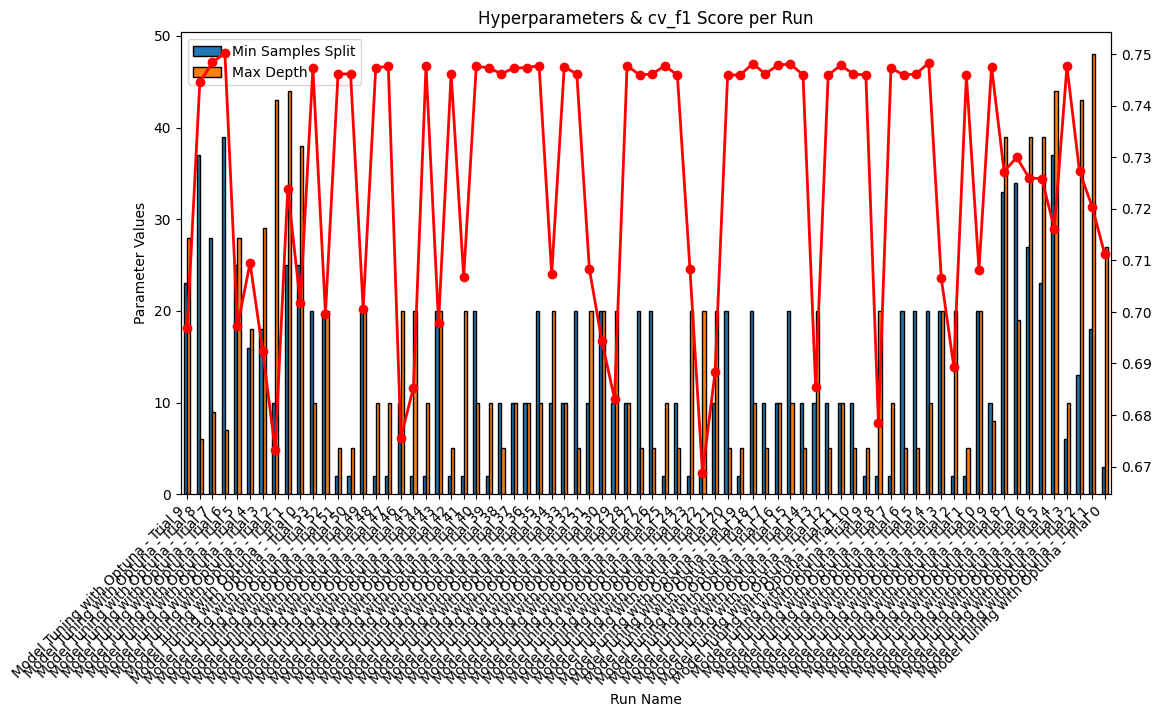

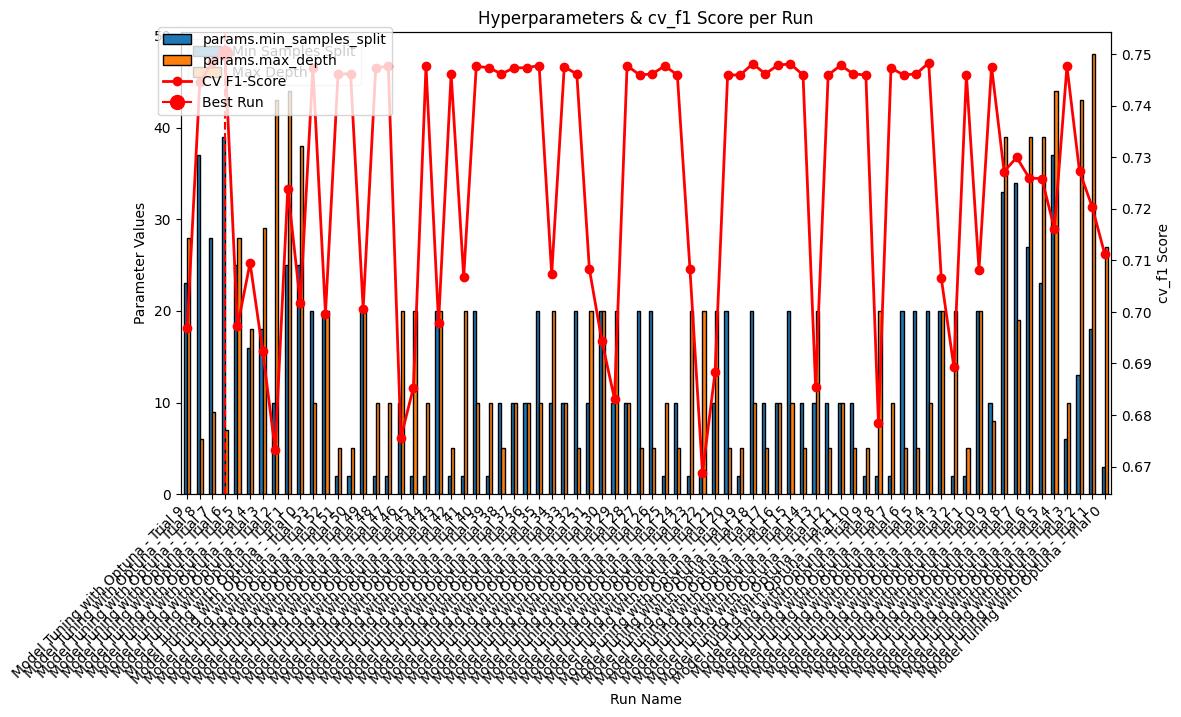

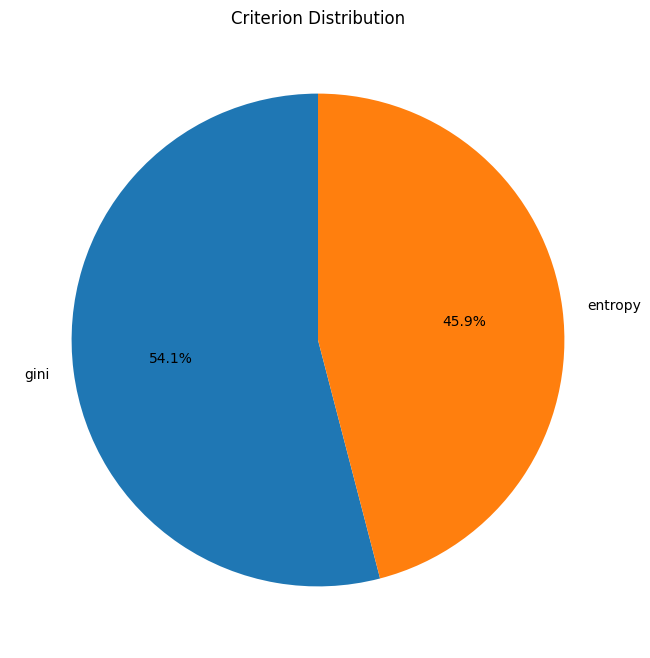

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Certifica-se de que os parâmetros necessários existem no DataFrame antes de plotar
required_params = [
    "params.min_samples_leaf", 
    "params.max_depth", 
    "params.min_samples_split", 
    "metrics.cv_f1", 
    "tags.mlflow.runName"
]

# Filtra o DataFrame original removendo linhas que contenham nulos nas colunas obrigatórias
#df_filtered = df_runs.dropna(subset=[p for p in required_params if p in df_runs.columns], how="any").copy()
df_filtered = df_runs.dropna(subset=required_params, how="any")


# 2. Converte os parâmetros numéricos para o tipo correto (float)
df_filtered["params.min_samples_split"] = df_filtered["params.min_samples_split"].astype(float)
df_filtered["params.max_depth"] = df_filtered["params.max_depth"].astype(float)
df_filtered["metrics.cv_f1"] = df_filtered["metrics.cv_f1"].astype(float)

# 3. Identifica o índice do melhor run de acordo com a métrica
# No código original, assume-se busca pelo valor máximo (idxmax). 
# Se o seu log salvou valores negativos para o Optuna minimizar, altere para .idxmin()
best_run_index = df_filtered["metrics.cv_f1"].idxmax()
best_run_name = df_filtered.loc[best_run_index, "tags.mlflow.runName"]

# 4. Extrai os nomes das runs para os rótulos do eixo X
run_names = df_filtered["tags.mlflow.runName"]

# 5. Cria a estrutura da figura e do primeiro eixo (Eixo Esquerdo - Barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Define as colunas que serão plotadas no gráfico de barras empilhadas ou agrupadas
# Nota: Ajustamos a sintaxe de plotagem para garantir total compatibilidade com o pandas local do Colab
df_filtered[["params.min_samples_split", "params.max_depth"]].plot(
    kind="bar", 
    ax=ax1, 
    edgecolor="black"
)

ax1.set_xlabel("Run Name")
ax1.set_ylabel("Parameter Values")
ax1.set_title("Hyperparameters & cv_f1 Score per Run")
ax1.legend(["Min Samples Split", "Max Depth"], loc="upper left")
ax1.set_xticks(range(len(df_filtered)))
ax1.set_xticklabels(run_names, rotation=45, ha="right")

# 6. Cria o segundo eixo Y (Eixo Direito - Linha para a Métrica)
ax2 = ax1.twinx()
ax2.plot(
    range(len(df_filtered)), 
    df_filtered["metrics.cv_f1"], 
    color="red", 
    marker="o", 
    linewidth=2, 
    label="CV F1-Score"
)
import matplotlib.pyplot as plt
import numpy as np

# 1. Certifica-se de que os parâmetros necessários existem no DataFrame antes de plotar
required_params = [
    "params.min_samples_leaf", 
    "params.max_depth", 
    "params.min_samples_split", 
    "metrics.cv_f1", 
    "tags.mlflow.runName"
]

# Filtra o DataFrame original removendo linhas que contenham nulos nas colunas obrigatórias
#df_filtered = df_runs.dropna(subset=[p for p in required_params if p in df_runs.columns], how="any").copy()
df_filtered = df_runs.dropna(subset=required_params, how="any")


# 2. Converte os parâmetros numéricos para o tipo correto (float)
df_filtered["params.min_samples_split"] = df_filtered["params.min_samples_split"].astype(float)
df_filtered["params.max_depth"] = df_filtered["params.max_depth"].astype(float)
df_filtered["metrics.cv_f1"] = df_filtered["metrics.cv_f1"].astype(float)

# 3. Identifica o índice do melhor run de acordo com a métrica
# No código original, assume-se busca pelo valor máximo (idxmax). 
# Se o seu log salvou valores negativos para o Optuna minimizar, altere para .idxmin()
best_run_index = df_filtered["metrics.cv_f1"].idxmax()
best_run_name = df_filtered.loc[best_run_index, "tags.mlflow.runName"]

# 4. Extrai os nomes das runs para os rótulos do eixo X
run_names = df_filtered["tags.mlflow.runName"]

# 5. Cria a estrutura da figura e do primeiro eixo (Eixo Esquerdo - Barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Define as colunas que serão plotadas no gráfico de barras empilhadas ou agrupadas
# Nota: Ajustamos a sintaxe de plotagem para garantir total compatibilidade com o pandas local do Colab
df_filtered[["params.min_samples_split", "params.max_depth"]].plot(
    kind="bar", 
    ax=ax1, 
    edgecolor="black"
)

ax1.set_xlabel("Run Name")
ax1.set_ylabel("Parameter Values")
ax1.set_title("Hyperparameters & cv_f1 Score per Run")
ax1.legend(["Min Samples Split", "Max Depth"], loc="upper left")
ax1.set_xticks(range(len(df_filtered)))
ax1.set_xticklabels(run_names, rotation=45, ha="right")

# 6. Cria o segundo eixo Y (Eixo Direito - Linha para a Métrica)
ax2 = ax1.twinx()
ax2.plot(
    range(len(df_filtered)), 
    df_filtered["metrics.cv_f1"], 
    color="red", 
    marker="o", 
    linewidth=2, 
    label="CV F1-Score"
)

# -------------------------------------------------------------------------
# CONTINUAÇÃO DA PLOTAGEM DUAL-AXIS (Destaque da melhor Run)
# -------------------------------------------------------------------------

# Adiciona o marcador em destaque para a melhor Run na linha do F1-Score
ax2.plot(
    df_filtered.index.get_loc(best_run_index),  # Obtém o índice posicional
    df_filtered.loc[best_run_index, "metrics.cv_f1"],
    marker="o",
    markersize=10,
    color="red",
    label="Best Run"
)

# Adiciona uma linha vertical tracejada vermelha cruzando todo o gráfico no ponto da melhor Run
ax2.axvline(
    df_filtered.index.get_loc(best_run_index), 
    color="red", 
    linestyle="--"
)

ax2.set_ylabel("cv_f1 Score")

# Adiciona a legenda geral da figura combinando ambos os eixos
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


# -------------------------------------------------------------------------
# NOVO GRÁFICO: Distribuição do Hyperparâmetro Criterion (Pie Chart)
# -------------------------------------------------------------------------

plt.figure(figsize=(8, 8))

# Calcula a frequência dos critérios testados ('gini' vs 'entropy') e plota em pizza
df_filtered["params.criterion"].value_counts().plot(
    kind="pie", 
    autopct="%1.1f%%", 
    startangle=90
)

plt.title("Criterion Distribution")
plt.ylabel("")  # Oculta o label do eixo Y para melhorar a estética visual
plt.show()



## Load the Best Model and Parameters

To load the model and make a prediction, let's use the information from Option 2 shown above. Run the next cell to get the value.

### Copy and Paste Option

Alternatively, you can set the variables shown below manually. Using either the output from Option 1 or Option 2 or the UI from Option 3, locate the `run_id` and the `experiment_id`. With Option 1 or 2, this is simply the value in the first two columns. In the UI, this is presented to you in the Details table when clicking on the specific run.

In [0]:




import mlflow
import json

# 1. Extrai o run_id e o experiment_id diretamente do DataFrame do Pandas (search_runs_pd)
# que geramos na etapa anterior (Opção 1)
if not search_runs_pd.empty:
    run_id = search_runs_pd.loc[0, "run_id"]
    experiment_id = search_runs_pd.loc[0, "experiment_id"]
else:
    # Fallback manual caso você queira apenas colar os IDs da UI do MLflow
    run_id = "b7d0cb2a09f34c3595514c7930d02c69"  
    experiment_id = "3533291678227437"

print(f"Run ID: {run_id}")
print(f"Experiment ID: {experiment_id}")

# 2. Captura um exemplo de entrada do conjunto de teste (Pandas DataFrame)
# Certifique-se de que a variável X_test já existe na memória do seu notebook
if 'X_test' in locals():
    input_example = X_test.iloc[[0]]
else:
    # Fallback temporário usando o X_train caso o X_test não tenha sido declarado antes
    input_example = X_train.iloc[[0]]

# 3. Reconstrói a URI lógica do artefato do MLflow para apontar para o modelo salvo
# (Funciona perfeitamente independente se os artefatos estão no DBFS, S3 ou localmente no Colab)
model_uri = f"runs:/{run_id}/decision_tree_model"
print(f"Model URI: {model_uri}")

Run ID: 3862603601a940649f5ee0301ef95266
Experiment ID: 3412365139594935
Model URI: runs:/3862603601a940649f5ee0301ef95266/decision_tree_model


In [0]:
model_uri

'runs://3862603601a940649f5ee0301ef95266/decision_tree_model'

In [0]:
import mlflow
import json

# 1. Captura um exemplo de entrada do conjunto de dados de teste (Pandas DataFrame)
# Garantimos um fallback seguro caso X_test ou X_train mude de nome no seu ambiente local
if 'X_test' in locals():
    input_example = X_test.iloc[[0]]
elif 'X_train' in locals():
    input_example = X_train.iloc[[0]]
else:
    raise NameError("Dataset de treino/teste não localizado na memória. Execute as células iniciais.")

# 2. Constrói a URI apontando para o artefato salvo na árvore do MLflow
model_uri = f"runs:/{run_id}/decision_tree_model"
#errado => model_uri = f"runs://{run_id}/decision_tree_model"
print(f"Loading model from URI: {model_uri}")

# 3. Carrega o modelo de forma genérica usando pyfunc para máxima compatibilidade
loaded_model = mlflow.pyfunc.load_model(model_uri)

# 4. Recupera todos os parâmetros brutos diretamente da execução através do MlflowClient
client = mlflow.tracking.MlflowClient()
run_data = client.get_run(run_id).data
params = run_data.params

# Exibe os parâmetros formatados em uma estrutura JSON limpa
print("\n[INFO] Best Model Parameters:")
print(json.dumps(params, indent=4))

# 5. (Opcional) Teste de Sanidade: Executa uma predição rápida no Colab
pred = loaded_model.predict(input_example)

print("-" * 50)
print(f"Sanity Check Prediction Output: {pred}")

Loading model from URI: runs:/3862603601a940649f5ee0301ef95266/decision_tree_model



[INFO] Best Model Parameters:
{
    "criterion": "gini",
    "max_depth": "20",
    "min_samples_leaf": "1",
    "min_samples_split": "2"
}
--------------------------------------------------
Sanity Check Prediction Output: [0.]


## Make a Prediction

With the winning model successfully reloaded from MLflow into your local memory, you can perform batch or single-instance inference. 

In this section, we will pass a test sample through the model's pipeline, extract the prediction vector, and append it back onto the original feature space as a new column for direct interpretation and downstream auditing.

In [0]:
# 1. Realiza a predição utilizando o modelo carregado previamente via pyfunc
# O input_example deve ser um DataFrame estruturado com as mesmas colunas usadas no treino
test_prediction = loaded_model.predict(input_example)

# 2. Clona o exemplo de entrada para evitar o "SettingWithCopyWarning" do Pandas
# Esse warning (exibido no Databricks) ocorre ao tentar modificar uma fatia de uma matriz direta.
input_sample_with_pred = input_example.copy()

# 3. Adiciona os outputs gerados pelo modelo como uma nova coluna à direita do DataFrame
input_sample_with_pred['prediction'] = test_prediction

# 4. Exibe o resultado de forma estruturada na tela do Colab
input_sample_with_pred

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,prediction
44967,0.0,1.0,1.0,23.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,10.0,4.0,5.0,0.0


# Register the Model to Unity Catalog

In [0]:

mlflow.set_registry_uri("databricks-uc")


model_uri = f'runs:/{run_id}/decision_tree_model'
# catalog_name. schema_name.arquivo
mlflow.register_model(model_uri=model_uri, name=f"workspace.default.demo_optuna_model")

Registered model 'workspace.default.demo_optuna_model' already exists. Creating a new version of this model...
2026/05/31 03:07:12 WARNING mlflow.tracking._model_registry.fluent: Run with id 3862603601a940649f5ee0301ef95266 has no artifacts at artifact path 'decision_tree_model', registering model based on models:/m-d76ae9bfc03e415b8a8f8ae721466eef instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.default.demo_optuna_model': https://dbc-0b69ef93-5247.cloud.databricks.com/explore/data/models/workspace/default/demo_optuna_model/version/2?o=7474657872577658


<ModelVersion: aliases=[], creation_timestamp=1780196835067, current_stage=None, deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1780196838464, metrics=[<Metric: dataset_digest='', dataset_name='', key='cv_accuracy', model_id='m-d76ae9bfc03e415b8a8f8ae721466eef', run_id='3862603601a940649f5ee0301ef95266', step=0, timestamp=1780193759664, value=0.6674659008705248>,
 <Metric: dataset_digest='', dataset_name='', key='cv_f1', model_id='m-d76ae9bfc03e415b8a8f8ae721466eef', run_id='3862603601a940649f5ee0301ef95266', step=0, timestamp=1780193759856, value=0.6687115313753966>,
 <Metric: dataset_digest='', dataset_name='', key='cv_precision', model_id='m-d76ae9bfc03e415b8a8f8ae721466eef', run_id='3862603601a940649f5ee0301ef95266', step=0, timestamp=1780193759726, value=0.6660591785847583>,
 <Metric: d

![image_1780196500238.png](./image_1780196500238.png "image_1780196500238.png")

![image_1780196895142.png](./image_1780196895142.png "image_1780196895142.png")

## Conclusion

In this demo, we've explored how to enhance your model's performance using **Optuna** for hyperparameter optimization and **MLflow** for tracking the tuning process. 

By employing Optuna's efficient search algorithms, you've learned to fine-tune your model's parameters effectively. Simultaneously, MLflow has facilitated seamless monitoring and logging of each trial, capturing essential information such as hyperparameters, metrics, and intermediate results. 

Additionally, you learned how to programmatically query the experiment history, isolate the top-performing iteration, run local batch inference, and register the best model within the registry workspace. Moving forward, integrating these tools into your workflow will be instrumental in improving your model's performance and simplifying the fine-tuning process.